# Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from scipy.stats import randint, uniform
from xgboost import XGBClassifier


In [2]:
# Load dataset
!git clone https://github.com/Leo-Thomas/EngineFaultDB.git
df = pd.read_csv('/content/EngineFaultDB/EngineFaultDB_Final.csv')
df = df.drop_duplicates()

Cloning into 'EngineFaultDB'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 31 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 1.74 MiB | 7.20 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [4]:
def add_engine_features(df):
    # Row-level feature engineering only.
    # Keep this function available, but use USE_ENGINEERED_FEATURES=False below
    # if you want to prove that feature engineering is not causing leakage.
    df = df.copy()
    eps = 1e-8
    df['load_index'] = df['MAP'] * df['TPS'] / (df['RPM'] + eps)
    df['power_per_rpm'] = df['Power']/(df['RPM']+eps)
    df['lambda_dev'] = np.abs(df['Lambda'] - 1)
    df['afr_dev'] = np.abs(df['AFR'] - 14.7)
    df['o2_co2_ratio'] = df['O2']/(df['CO2']+eps)
    df['co2_minus_o2'] = df['CO2'] - df['O2']
    df['combustion_efficiency'] = df['CO2']/(df['CO2']+df['CO']+df['HC']/1e4+eps)
    df['rich_flag'] = (df['Lambda'] < 1).astype(int)
    df['map_x_tps'] = df['MAP']*df['TPS']
    df['rpm_tps_ratio'] = df['RPM'] / (df['TPS'] + eps)
    df['map_rpm_ratio'] = df['MAP'] / (df['RPM'] + eps)
    df['power_load_ratio'] = df['Power'] / (df['MAP'] * df['TPS'] + eps)
    df['lambda_x_load'] = df['Lambda'] * df['load_index']
    df['afr_x_load'] = df['AFR'] * df['load_index']
    df['hc_co_ratio'] = df['HC'] / (df['CO'] + eps)
    df['co_hc_combined'] = df['CO'] + df['HC'] / 1000
    df['emission_intensity'] = (df['CO'] + df['HC']/1000 + df['CO2']) / (df['Power'] + eps)
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    return df


def make_kmeans_condition_groups(X, n_clusters=80, random_state=42):
    """
    Creates similarity-based groups using KMeans.

    Why this is used:
    - The dataset does not include an engine_id, run_id, batch_id, or timestamp.
    - A normal random split can place highly similar engine states in both train and test.
    - KMeans groups similar operating conditions, then GroupShuffleSplit keeps whole groups
      in either train OR test to reduce dependency leakage.

    Note:
    - This grouping is unsupervised and uses features only, not labels.
    - If a real run_id / engine_id exists, that should be preferred over KMeans groups.
    """
    X_for_grouping = X.copy()
    X_for_grouping = X_for_grouping.replace([np.inf, -np.inf], np.nan).fillna(0)

    group_scaler = StandardScaler()
    X_group_scaled = group_scaler.fit_transform(X_for_grouping)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    groups = kmeans.fit_predict(X_group_scaled)
    return pd.Series(groups, index=X.index, name='kmeans_group')


# ------------------------------------------------------------
# Target preparation
# ------------------------------------------------------------
# Combine class 2 and 3, as recommended by the lecturer.
df['Fault_Combined'] = df['Fault'].replace({3: 2})

# Use only raw predictors here. Do NOT include Fault or Fault_Combined.
X_base = df.drop(['Fault', 'Fault_Combined'], axis=1)
y = df['Fault_Combined']

# Optional aggressive near-duplicate removal.
# This rounds raw feature values before duplicate removal to reduce near-identical observations.
# Keep it disabled by default so the notebook remains close to the original dataset.
AGGRESSIVE_NEAR_DUPLICATE_REMOVAL = False

if AGGRESSIVE_NEAR_DUPLICATE_REMOVAL:
    temp = X_base.round(3).copy()
    temp['Fault_Combined'] = y.values
    before = len(temp)
    temp = temp.drop_duplicates()
    after = len(temp)
    print(f'Removed {before - after} near-duplicate rows after rounding.')
    y = temp['Fault_Combined']
    X_base = temp.drop(columns=['Fault_Combined'])

# ------------------------------------------------------------
# Leakage-aware KMeans grouped split
# ------------------------------------------------------------
# Stronger grouping than single-feature binning: clusters similar rows across ALL raw features.
groups = make_kmeans_condition_groups(X_base, n_clusters=80, random_state=42)

# GroupShuffleSplit keeps each KMeans cluster entirely in train or test.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_base, y, groups=groups))

X_train_base = X_base.iloc[train_idx].copy()
X_test_base = X_base.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

# ------------------------------------------------------------
# Feature engineering option
# ------------------------------------------------------------
# Recommendation: keep this False for the leakage investigation.
# Set to True later only if you want to compare raw vs engineered performance.
USE_ENGINEERED_FEATURES = False

if USE_ENGINEERED_FEATURES:
    X_train_raw = add_engine_features(X_train_base)
    X_test_raw = add_engine_features(X_test_base)
else:
    X_train_raw = X_train_base.copy()
    X_test_raw = X_test_base.copy()

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
train_groups = set(groups_train)
test_groups = set(groups_test)
group_overlap = train_groups.intersection(test_groups)

print('Train shape:', X_train_raw.shape)
print('Test shape:', X_test_raw.shape)
print('Train class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('Test class distribution:')
print(y_test.value_counts(normalize=True).sort_index())
print('Number of KMeans groups:', groups.nunique())
print('Overlapping KMeans groups between train and test:', len(group_overlap))

# Exact duplicate feature-row overlap check after the split.
overlap_rows = pd.merge(
    X_train_raw.reset_index(drop=True),
    X_test_raw.reset_index(drop=True),
    how='inner'
)
print('Exact overlapping feature rows between train and test:', len(overlap_rows))

# Scale using train data only.
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

Train shape: (43086, 14)
Test shape: (12912, 14)
Train class distribution:
Fault_Combined
0    0.287750
1    0.182147
2    0.530103
Name: proportion, dtype: float64
Test class distribution:
Fault_Combined
0    0.278965
1    0.243959
2    0.477076
Name: proportion, dtype: float64
Number of KMeans groups: 80
Overlapping KMeans groups between train and test: 0
Exact overlapping feature rows between train and test: 0


In [5]:
# Macro-F1 metric
# This is used to keep the same evaluation focus as the original notebook.
def macro_f1_eval(y_pred_probs, dtrain):
    y_true = dtrain.get_label()
    y_pred_probs = y_pred_probs.reshape(len(y_true), -1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    return 'macro_f1', f1_score(y_true, y_pred, average='macro')

model = XGBClassifier(
    objective='multi:softprob',
    eval_metric=macro_f1_eval,
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print('Macro-F1:', f1_score(y_test, y_pred, average='macro'))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      3602
           1       1.00      0.68      0.81      3150
           2       0.99      1.00      0.99      6160

    accuracy                           0.92     12912
   macro avg       0.93      0.89      0.90     12912
weighted avg       0.94      0.92      0.92     12912

Macro-F1: 0.897022512804296


## Split Method Used in This Version

This version keeps the XGBoost model but changes the evaluation design. Instead of a normal random split, it uses KMeans to create groups of similar engine operating conditions from the raw features. `GroupShuffleSplit` then keeps each cluster fully in either the train set or test set. This reduces the risk that near-identical observations appear in both partitions.

The label-shuffle test should be checked after this split. If the shuffle score remains much higher than the dummy baseline, the dataset may still contain non-independent observations that cannot be fully resolved without a real `engine_id`, `run_id`, `batch_id`, or time-based split.


# Leakage / Split Sanity Checks


In [7]:
# Dummy baseline: the real model should perform clearly better than this.
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print('Dummy baseline classification report:')
print(classification_report(y_test, dummy_pred, zero_division=0))
print('Dummy baseline Macro-F1:', f1_score(y_test, dummy_pred, average='macro'))

# Label-shuffle sanity check:
# If performance remains high after training on shuffled labels, there may still be data dependence/leakage.
y_train_shuffled = y_train.sample(frac=1, random_state=42).to_numpy()

shuffle_model = XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
)

shuffle_model.fit(X_train, y_train_shuffled)
shuffle_pred = shuffle_model.predict(X_test)

print('Label-shuffle classification report:')
print(classification_report(y_test, shuffle_pred, zero_division=0))
print('Label-shuffle Macro-F1:', f1_score(y_test, shuffle_pred, average='macro'))

Dummy baseline classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3602
           1       0.00      0.00      0.00      3150
           2       0.48      1.00      0.65      6160

    accuracy                           0.48     12912
   macro avg       0.16      0.33      0.22     12912
weighted avg       0.23      0.48      0.31     12912

Dummy baseline Macro-F1: 0.21532438478747204
Label-shuffle classification report:
              precision    recall  f1-score   support

           0       0.32      0.07      0.12      3602
           1       0.87      0.19      0.32      3150
           2       0.51      0.94      0.66      6160

    accuracy                           0.52     12912
   macro avg       0.57      0.40      0.36     12912
weighted avg       0.54      0.52      0.42     12912

Label-shuffle Macro-F1: 0.3649234244391845


# Tuning

In [ ]:
# Tuning
# Group-aware CV is used so similar KMeans groups are not split across CV folds.
param_dist = {
    'n_estimators': randint(200, 900),
    'learning_rate': uniform(0.02, 0.15),
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1.0),
    'reg_lambda': uniform(1, 10),
}

xgb_tune = XGBClassifier(
    objective='multi:softprob',
    eval_metric=macro_f1_eval,
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit with groups so cross-validation is also leakage-aware.
random_search.fit(X_train, y_train, groups=groups_train.to_numpy())

best_xgb = random_search.best_estimator_

print('
Best Parameters Found:')
print(random_search.best_params_)

# Evaluation on the untouched KMeans-grouped test set.
y_pred = best_xgb.predict(X_test)
print('
Classification Report (Tuned XGBoost - KMeans Grouped Split):')
print(classification_report(y_test, y_pred, zero_division=0))
print('Macro-F1:', f1_score(y_test, y_pred, average='macro'))


# Final Model

In [9]:
# Final model using the tuned parameters from the earlier notebook.
# You can replace tuned_params with random_search.best_params_ after running the tuning cell.
tuned_params = {
    'colsample_bytree': 0.7933755828319241,
    'gamma': 0.482627653632069,
    'learning_rate': 0.1110551371530027,
    'max_depth': 7,
    'min_child_weight': 1,
    'n_estimators': 356,
    'reg_alpha': 0.8021969807540397,
    'reg_lambda': 1.7455064367977082,
    'subsample': 0.9947547746402069
}

new_xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric=macro_f1_eval,
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
    **tuned_params
)

new_xgb_model.fit(X_train, y_train)

y_pred_tuned = new_xgb_model.predict(X_test)

print('Classification Report (XGBoost with Tuned Parameters - KMeans Grouped Split):')
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print('Macro-F1:', f1_score(y_test, y_pred_tuned, average='macro'))

Classification Report (XGBoost with Tuned Parameters - KMeans Grouped Split):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3602
           1       1.00      0.68      0.81      3150
           2       0.86      1.00      0.92      6160

    accuracy                           0.92     12912
   macro avg       0.95      0.89      0.91     12912
weighted avg       0.93      0.92      0.92     12912

Macro-F1: 0.911799491306191


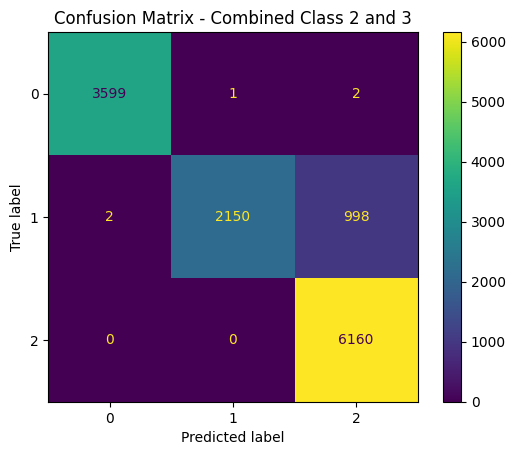

Macro-F1: 0.911799491306191


In [10]:
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix - Combined Class 2 and 3')
plt.show()

print("Macro-F1:", f1_score(y_test, y_pred_tuned, average='macro'))

# SHAP Explainability

In [ ]:
explainer = shap.TreeExplainer(new_xgb_model)
shap_values = explainer.shap_values(X_test)

feature_names = X_train_raw.columns.tolist()

class_labels = sorted(y.unique())

for i in range(len(class_labels)):
    if i < shap_values.shape[2]:
        print(f'
Generating SHAP summary plot for Class {class_labels[i]}...')
        shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names, show=False)
        plt.title(f'SHAP Summary Plot for Class {class_labels[i]}')
        plt.show()
    else:
        print(f'Warning: No SHAP values available for class index {i}')
